# Random Forest Model Training


## Load Cleaned Data


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from math import prod
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

clean_train = pd.read_csv("data/clean_train.csv")
clean_val = pd.read_csv("data/clean_val.csv")

# The cleaned CSVs keep Place_ID and Date for feature engineering, but models should not train on them.
metadata_cols = ["Place_ID", "Date", "Place_ID X Date"]
drop_cols = ["target"] + [col for col in metadata_cols if col in clean_train.columns]

X_tr = clean_train.drop(columns=drop_cols)
y_tr = clean_train["target"]
X_val = clean_val.drop(columns=drop_cols)
y_val = clean_val["target"]

model_scores = {}
model_predictions = {}

print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr shape:", y_tr.shape)
print("y_val shape:", y_val.shape)


X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Target Transform


Target skewness: 2.09


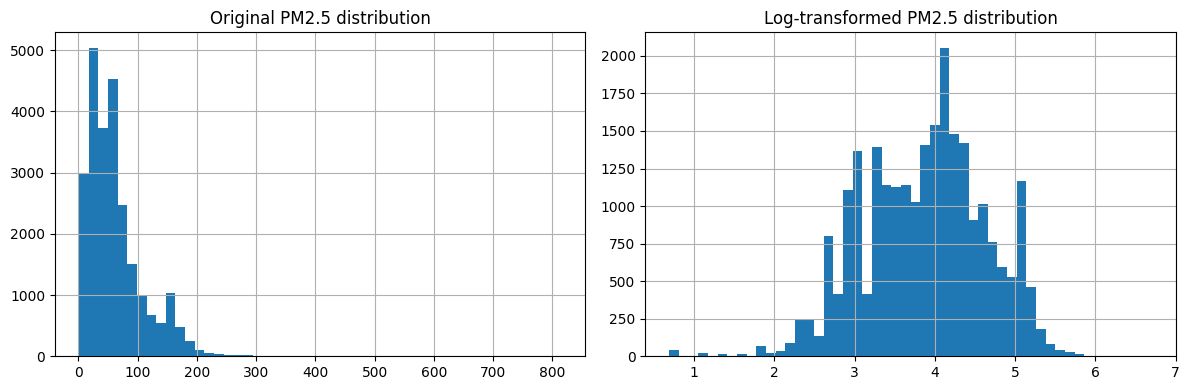

In [54]:
# Log-transform the target because PM2.5 is strongly right-skewed.
print(f"Target skewness: {y_tr.skew():.2f}")

y_tr_log = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
y_tr_log.hist(bins=50, ax=axes[1])
axes[1].set_title("Log-transformed PM2.5 distribution")
plt.tight_layout()
plt.show()


## Default Random Forest - All Features


In [55]:
# Partner version included this all-feature baseline; keep it as a simple comparison point.
rf_default_all = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
rf_default_all.fit(X_tr, y_tr_log)

y_val_pred_rf_default_all = np.expm1(rf_default_all.predict(X_val))
rmse_rf_default_all = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_default_all))

model_scores["RF default - all features"] = rmse_rf_default_all
model_predictions["RF default - all features"] = y_val_pred_rf_default_all

print(f"Default RF RMSE (all features): {rmse_rf_default_all:.2f} µg/m³")


Default RF RMSE (all features): 31.07 µg/m³


## Random Forest Feature Selection


Top 25 Random Forest features:
L3_AER_AI_sensor_altitude                              0.164419
L3_CO_CO_column_number_density                         0.131127
wind_speed_10m_above_ground                            0.104340
L3_HCHO_tropospheric_HCHO_column_number_density        0.059795
L3_NO2_NO2_column_number_density                       0.051302
temperature_2m_above_ground                            0.044214
L3_NO2_NO2_slant_column_number_density                 0.030609
specific_humidity_2m_above_ground                      0.027866
L3_NO2_tropopause_pressure                             0.020798
L3_CLOUD_surface_albedo                                0.020729
relative_humidity_2m_above_ground                      0.019774
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.016787
L3_NO2_sensor_altitude                                 0.015566
precipitable_water_entire_atmosphere                   0.015194
L3_O3_O3_column_number_density                         0.014080
L3_O3_O3_

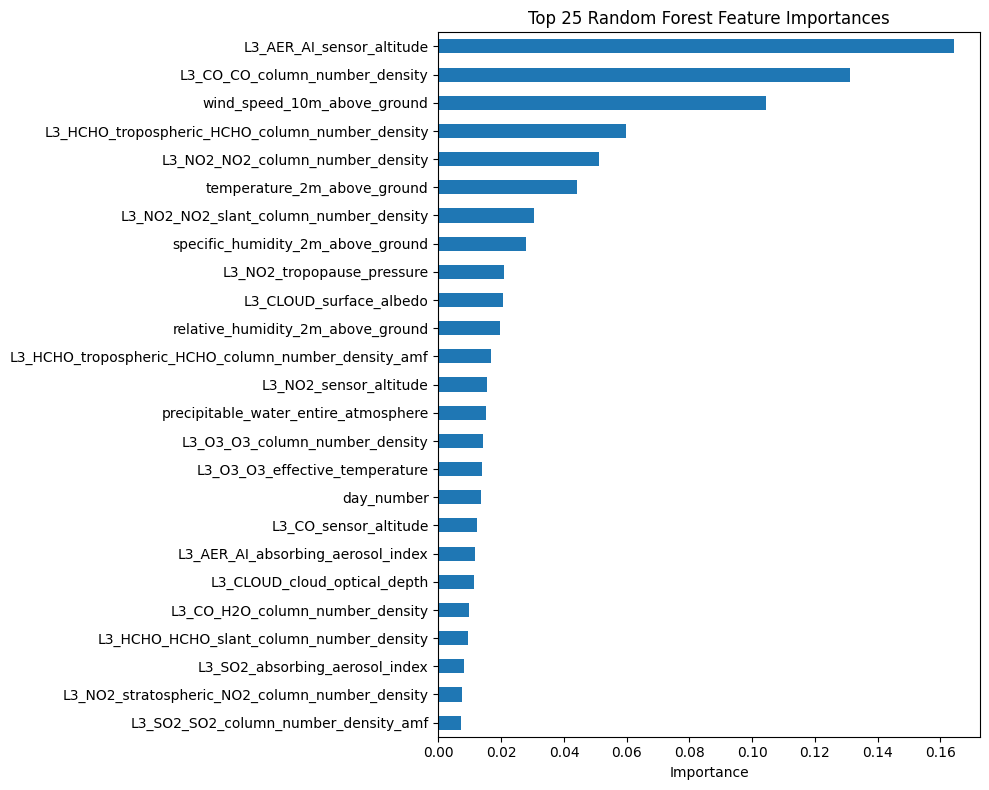

Saved RF top 25 features to data/best_features.csv


In [56]:
# Select the strongest 25 features with a moderately regularized RF selector.
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=None,
    random_state=42,
    n_jobs=-1,
)
rf_selector.fit(X_tr, y_tr_log)

rf_importance = pd.Series(rf_selector.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
top_features = rf_importance.head(25).index.tolist()

print("Top 25 Random Forest features:")
print(rf_importance.head(25))

rf_importance.head(25).sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Top 25 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Save RF features into the shared best_features file without overwriting other model columns.
best_features_path = "data/best_features.csv"
try:
    best_features = pd.read_csv(best_features_path)
except FileNotFoundError:
    best_features = pd.DataFrame()

rf_best_features = pd.DataFrame({
    "random_forest": rf_importance.head(25).index,
    "rf_feature_importance": rf_importance.head(25).values,
})

for col in rf_best_features.columns:
    best_features[col] = rf_best_features[col]

best_features.to_csv(best_features_path, index=False)
print(f"Saved RF top 25 features to {best_features_path}")


## Default Random Forest - Top 25 Features


In [57]:
X_tr_selected = X_tr[top_features]
X_val_selected = X_val[top_features]

rf_default_top25 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
rf_default_top25.fit(X_tr_selected, y_tr_log)

y_val_pred_rf_default_top25 = np.expm1(rf_default_top25.predict(X_val_selected))
rmse_rf_default_top25 = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_default_top25))

model_scores["RF default - top 25 features"] = rmse_rf_default_top25
model_predictions["RF default - top 25 features"] = y_val_pred_rf_default_top25

print(f"Default RF RMSE (top 25 features): {rmse_rf_default_top25:.2f} µg/m³")


Default RF RMSE (top 25 features): 31.19 µg/m³


## Optional Hyperparameter Search - All Features


In [58]:
# Keep this False unless you explicitly want to rerun the expensive all-feature search.
RUN_RF_ALL_FEATURES_SEARCH = False

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False],
}

if RUN_RF_ALL_FEATURES_SEARCH:
    search_rf_all = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_param_grid,
        n_iter=30,
        cv=5,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search_rf_all.fit(X_tr, y_tr_log)

    best_rf_all = search_rf_all.best_estimator_
    y_val_pred_rf_tuned_all = np.expm1(best_rf_all.predict(X_val))
    rmse_rf_tuned_all = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_tuned_all))

    model_scores["RF tuned - all features"] = rmse_rf_tuned_all
    model_predictions["RF tuned - all features"] = y_val_pred_rf_tuned_all

    print("Best all-feature RF params:", search_rf_all.best_params_)
    print(f"Tuned RF RMSE (all features): {rmse_rf_tuned_all:.2f} µg/m³")
else:
    print("Skipping all-feature RF hyperparameter search.")


Skipping all-feature RF hyperparameter search.


## Tuned Random Forest - Top 25 Features


In [59]:
# Use known good RF parameters by default; optionally replace them with a fresh search.
RUN_RF_TOP25_SEARCH = False

best_params = {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_leaf_nodes": None,
    "max_features": "sqrt",
    "max_depth": None,
}

if RUN_RF_TOP25_SEARCH:
    param_distributions = {
        "n_estimators": [200, 300, 500],
        "max_depth": [8, 12, 16, 20, None],
        "min_samples_leaf": [1, 2, 3, 5, 10],
        "min_samples_split": [2, 5, 10, 20],
        "max_features": ["sqrt", 0.5, 0.8, 1.0],
        "max_leaf_nodes": [None, 50, 100, 200, 500],
    }

    total_possible_combinations = prod(len(values) for values in param_distributions.values())
    print(f"Total possible combinations: {total_possible_combinations}")

    search_rf_top25 = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_distributions,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search_rf_top25.fit(X_tr_selected, y_tr_log)
    best_params = search_rf_top25.best_params_
    print("Best top-25 RF params:", best_params)

best_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
)
best_rf.fit(X_tr_selected, y_tr_log)

y_val_pred_rf_tuned_top25 = np.expm1(best_rf.predict(X_val_selected))
rmse_rf_tuned_top25 = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_tuned_top25))
mean_pm25 = y_tr.mean()

model_scores["RF tuned - top 25 features"] = rmse_rf_tuned_top25
model_predictions["RF tuned - top 25 features"] = y_val_pred_rf_tuned_top25

print("Best Random Forest hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\nValidation RMSE: {rmse_rf_tuned_top25:.2f} µg/m³")
print(f"Mean PM2.5: {mean_pm25:.2f} µg/m³")
print(f"RMSE as % of mean: {(rmse_rf_tuned_top25 / mean_pm25) * 100:.1f}%")


Best Random Forest hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 5
max_leaf_nodes: None
max_features: sqrt
max_depth: None

Validation RMSE: 31.50 µg/m³
Mean PM2.5: 62.03 µg/m³
RMSE as % of mean: 50.8%


## Random Forest Results Summary


                       Model      RMSE
   RF default - all features 31.065604
RF default - top 25 features 31.193457
  RF tuned - top 25 features 31.501014


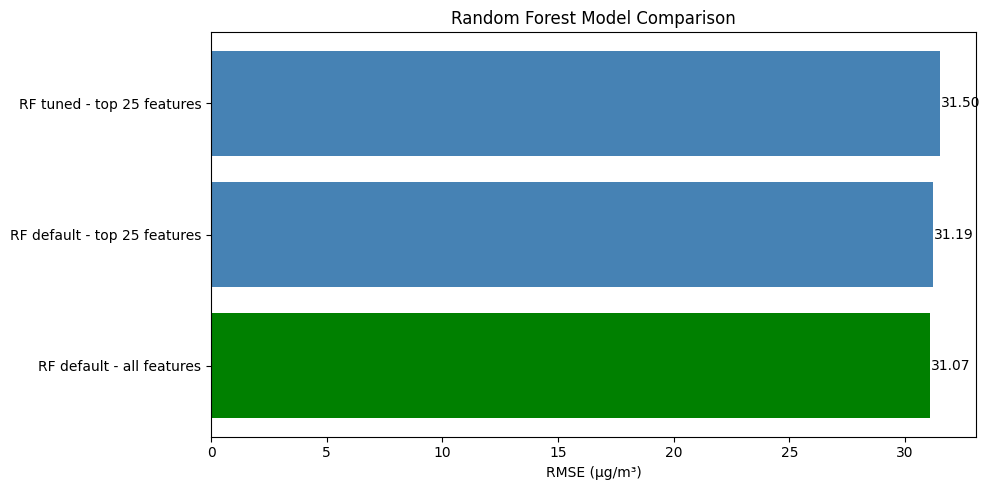

,Model,RMSE
0,RF default - all features,31.065604
1,RF default - top 25 features,31.193457
2,RF tuned - top 25 features,31.501014


In [60]:
rf_results = (
    pd.DataFrame({"Model": list(model_scores.keys()), "RMSE": list(model_scores.values())})
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(rf_results.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ["green" if rmse == rf_results["RMSE"].min() else "steelblue" for rmse in rf_results["RMSE"]]
plt.barh(rf_results["Model"], rf_results["RMSE"], color=colors)
plt.xlabel("RMSE (µg/m³)")
plt.title("Random Forest Model Comparison")
for i, value in enumerate(rf_results["RMSE"]):
    plt.text(value + 0.05, i, f"{value:.2f}", va="center")
plt.tight_layout()
plt.show()

rf_results


## Random Forest Diagnostics


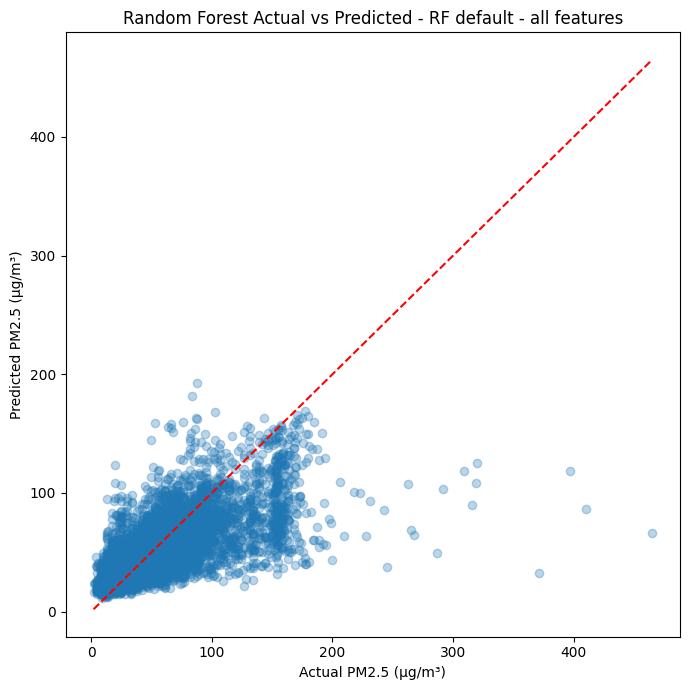

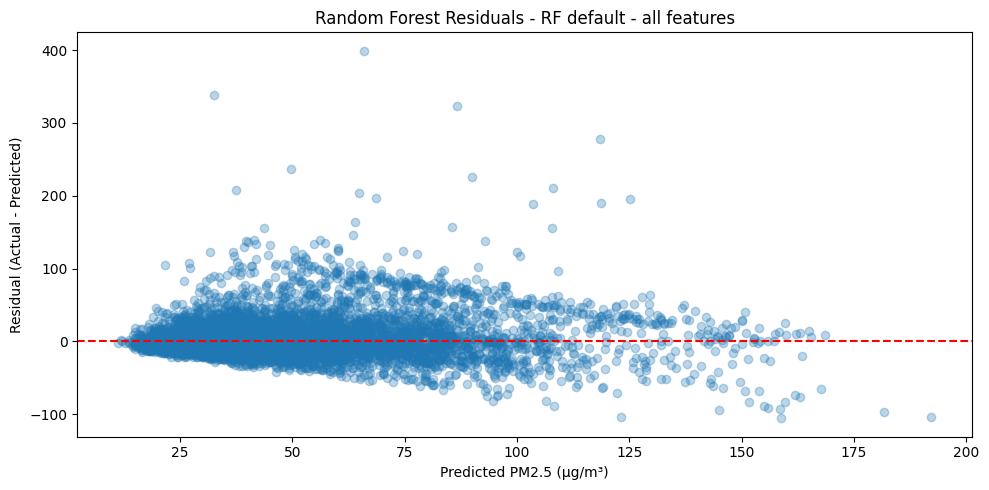

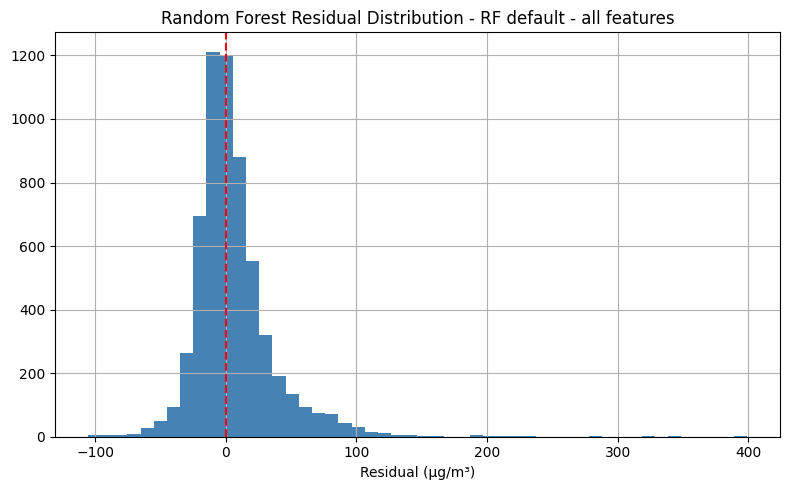

In [61]:
# Diagnose the strongest available RF model.
best_model_name = rf_results.loc[0, "Model"]
best_prediction = model_predictions[best_model_name]
residuals = y_val - best_prediction

plt.figure(figsize=(7, 7))
plt.scatter(y_val, best_prediction, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"Random Forest Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(best_prediction, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted PM2.5 (µg/m³)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Random Forest Residuals - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
residuals.hist(bins=50, color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (µg/m³)")
plt.title(f"Random Forest Residual Distribution - {best_model_name}")
plt.tight_layout()
plt.show()


## Target Summary


In [62]:
print(y_tr.describe())


count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64
